### Importação e Configuraçoes iniciais do projeto

**Importando bibliotecas fulcrais para o desenvolvimento do projeto**

In [63]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches

# Melhorar a visualização
%matplotlib inline
mpl.style.use('ggplot')
plt.style.use('fivethirtyeight')
sns.set(context='notebook', palette='dark', color_codes=True)

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import RandomizedSearchCV

# métricas de avaliação
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, auc, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, accuracy_score, classification_report

# Reamostragem dos dados
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import NearMiss, RandomUnderSampler

# Afins
import time
import pickle
import warnings
from numpy import interp
from pprint import pprint
from scipy.stats import norm
from collections import Counter
from imblearn.pipeline import Pipeline
from imblearn.pipeline import make_pipeline as imbalanced_make_pipeline

# Melhorar a visualização
%matplotlib inline
mpl.style.use('ggplot')
plt.style.use('fivethirtyeight')
sns.set(context='notebook', palette='dark', color_codes=True)

# Mensagens de warning
warnings.filterwarnings("ignore")

In [64]:
# Importar o conjunto de dados
dados_musicas = pd.read_csv('https://raw.githubusercontent.com/letpires/7DaysOfCodeSpotifyML/main/dataset.csv', index_col=0)

dados_musicas.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [65]:
dados_musicas.info() # Verificar informações úteis (e.g., quantidade de linhas, colunas e tipos de dados)

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

In [66]:
dados_musicas.describe() # Atributos numéricos

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Análise Exploratória de Dados (AED)

A análise exploratória de dados é uma etapa crucial para analisar o conjunto de dados e sintetizar suas características centrais, por meio de métodos visuais

In [67]:
dados_musicas.shape # Dimensão do DataFrame

(114000, 20)

In [68]:
dados_musicas.info()
dados_musicas.describe() # Visualizando as estatísticas

<class 'pandas.core.frame.DataFrame'>
Index: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


O dataset possui 113.999 entradas

In [69]:
# Artistas únicos
print(dados_musicas['artists'].unique().shape)

# Contagem de músicas por artista
print(dados_musicas['artists'].value_counts())

(31438,)
artists
The Beatles                           279
George Jones                          271
Stevie Wonder                         236
Linkin Park                           224
Ella Fitzgerald                       222
                                     ... 
Hillsong Worship;TAYA;David Ware        1
for KING & COUNTRY;Andy Mineo           1
Bethel Music;Francesca Battistelli      1
Descansa                                1
Jesus Culture                           1
Name: count, Length: 31437, dtype: int64


**Verificar valores ausentes**

In [70]:
# Ordenar em ordem decrescente as variáveis por seus valores ausentes
(dados_musicas.isnull().sum() / dados_musicas.shape[0]).sort_values(ascending=False)

,0
artists,0.000009
album_name,0.000009
track_name,0.000009
track_id,0.000000
popularity,0.000000
duration_ms,0.000000
explicit,0.000000
danceability,0.000000
energy,0.000000
key,0.000000


In [71]:
dados_musicas.isnull().sum()

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [72]:
# Função que gera um gráfico de barras com colunas e frequência dos dados faltantes

def missing_visualization(df):
  quant_isnull = df.isnull().sum()
  columns = df.columns
  dic = {"colunas":[],"quant_isnull":[]}
  for coluna, quant in zip(columns, quant_isnull):
    if quant > 0:
      dic["colunas"].append(quant)
      dic["quant_isnull"].append(coluna)
  df = pd.DataFrame(dic)
  plt.figure(figsize=(15,5))
  sns.barplot(x=df["quant_isnull"],y=df["colunas"],data=df, palette="rocket")
  plt.xticks(rotation=45);


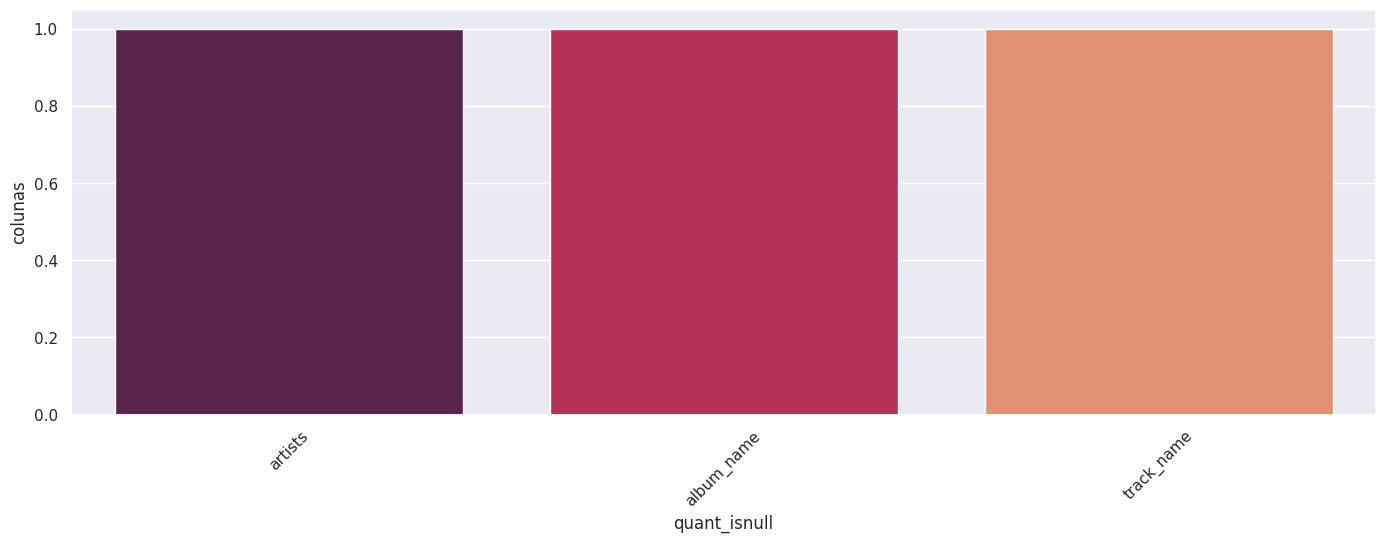

In [73]:
missing_visualization(dados_musicas)

**Respondendo algumas perguntas atinentes aos dados**


Quais as 100 músicas mais populares versus todo o conjunto de dados?


In [74]:
sorted_df = dados_musicas.sort_values('popularity', ascending=False).head(100)
sorted_df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,pop
20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance
51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop
89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton
30003,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,edm


In [75]:
dados_musicas.isna().sum() # Checando os valores nulos

,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0
key,0


In [76]:
dados_musicas.shape

(114000, 20)

In [77]:
dados_musicas.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [78]:
dados_musicas.duration_ms

,duration_ms
0,230666
1,149610
2,210826
3,201933
4,198853
...,...
113995,384999
113996,385000
113997,271466
113998,283893


In [79]:
artistas_popularidade = dados_musicas[['artists', 'popularity']]
artistas_populares = artistas_popularidade.groupby('artists').mean().sort_values(by='popularity', ascending=False).reset_index() # Ordenado pelos artistas mais populares

# Trazendo somente os cinco primeiros
artistas_populares = artistas_populares.head()
artistas_populares

,artists,popularity
0,Sam Smith;Kim Petras,100.0
1,Bizarrap;Quevedo,99.0
2,Manuel Turizo,98.0
3,Bad Bunny;Chencho Corleone,97.0
4,Bad Bunny;Bomba Estéreo,94.5


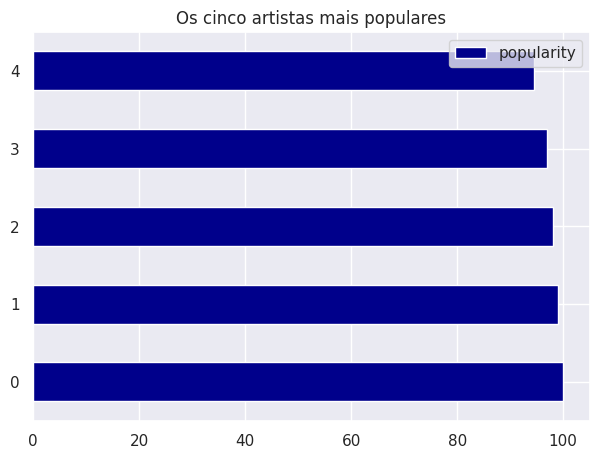

In [80]:
# Buscar os outliers (valroes discrepantes)
artistas_populares.plot.barh(color="darkblue") # Visualizar os dados
plt.title("Os cinco artistas mais populares")
plt.show()

In [81]:
long_songs = dados_musicas[["track_name", "duration_ms"]].sort_values(by="duration_ms", ascending=False)[:5]
long_songs

,track_name,duration_ms
73617,Unity (Voyage Mix) Pt. 1,5237295
10935,Crossing Wires 002 - Continuous DJ Mix,4789026
10984,Crossing Wires 002 - Continuous DJ Mix,4789026
24348,The Lab 03 - Continuous DJ Mix Part 1,4730302
73840,Amnesia Ibiza Underground 10 DJ Mix,4563897


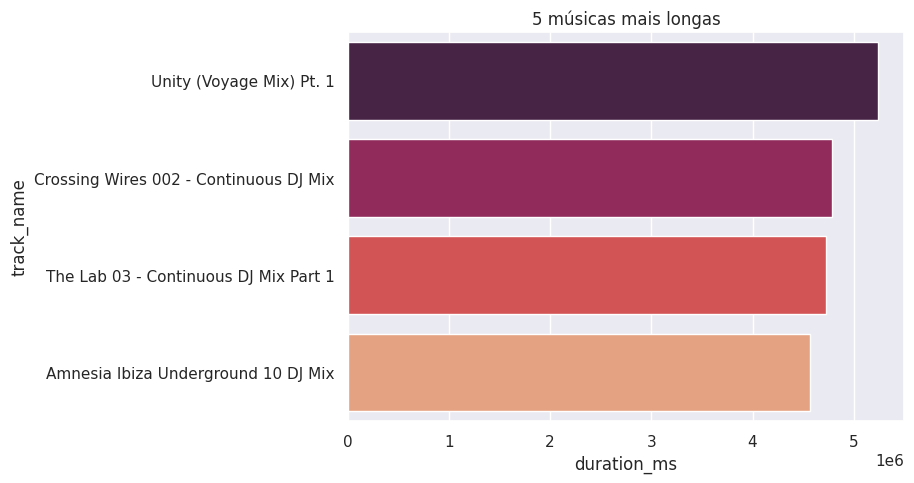

In [82]:
sns.barplot(x="duration_ms", y="track_name", data=long_songs, palette="rocket")
plt.title("5 músicas mais longas")
plt.show()

In [83]:
trend_genre = dados_musicas[["track_genre", "popularity"]].sort_values(by="popularity", ascending=False)[:5] # Os cinco gêneros musicais mais populares
trend_genre

,track_genre,popularity
81051,pop,100
20001,dance,100
51664,hip-hop,99
89411,reggaeton,98
30003,edm,98


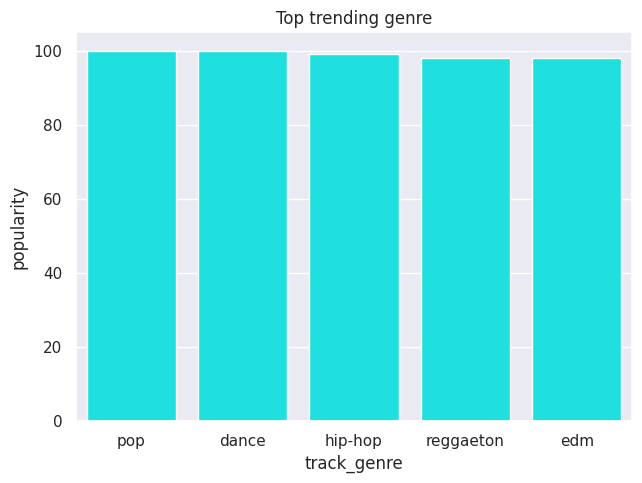

In [84]:
sns.barplot(x="track_genre",y="popularity", data=trend_genre, color = 'cyan')
plt.title("Top trending genre")
plt.show()

In [85]:
danceable = dados_musicas[["track_name", "artists", "danceability"]].sort_values(by="danceability", ascending=False)[:5]
danceable

,track_name,artists,danceability
111635,Sol Clap,Quantic,0.985
66576,Medicaid Baby,That Girl Lay Lay,0.984
24916,Inspiration,Delano Smith,0.983
73374,Daily Routines,Oliver Schories,0.982
66793,"Featuring Mixx Master Lee, Red Rum & J. Smoov ...",Mixx Master Lee,0.981


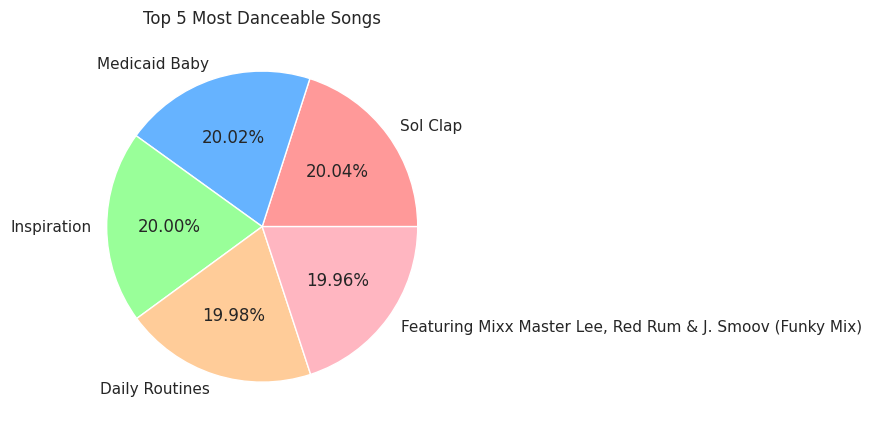

In [86]:
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#ffb6c1']

plt.pie(x="danceability", data=danceable, autopct='%1.2f%%', labels=danceable.track_name, colors = colors)
plt.title("Top 5 Most Danceable Songs")
plt.show()

In [87]:
#Encontrando correlação entre as variáveis

dados_musicas.describe()


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [88]:
numeric_cols = dados_musicas.select_dtypes(include=[np.number])
corr_table = numeric_cols.corr(method="pearson") # Dando a correlação entre as variáveis

In [89]:
corr_table

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007101,0.035448,0.001056,-0.003853,0.050423,-0.013931,-0.044927,-0.025472,-0.095139,-0.005387,-0.040534,0.013205,0.031073
duration_ms,-0.007101,1.000000,-0.073426,0.058523,0.008114,-0.003470,-0.035556,-0.062600,-0.103788,0.124371,0.010321,-0.154479,0.024346,0.018225
danceability,0.035448,-0.073426,1.000000,0.134325,0.036469,0.259077,-0.069219,0.108626,-0.171533,-0.185606,-0.131617,0.477341,-0.050450,0.207218
energy,0.001056,0.058523,0.134325,1.000000,0.048006,0.761690,-0.078362,0.142509,-0.733906,-0.181879,0.184796,0.258934,0.247851,0.187126
key,-0.003853,0.008114,0.036469,0.048006,1.000000,0.038590,-0.135916,0.020418,-0.040937,-0.006823,-0.001600,0.034103,0.010917,0.015065
loudness,0.050423,-0.003470,0.259077,0.761690,0.038590,1.000000,-0.041764,0.060826,-0.589803,-0.433477,0.076899,0.279848,0.212446,0.191992
mode,-0.013931,-0.035556,-0.069219,-0.078362,-0.135916,-0.041764,1.000000,-0.046532,0.095553,-0.049955,0.014012,0.021953,0.000566,-0.024092
speechiness,-0.044927,-0.062600,0.108626,0.142509,0.020418,0.060826,-0.046532,1.000000,-0.002186,-0.089616,0.205219,0.036635,0.017273,-0.000011
acousticness,-0.025472,-0.103788,-0.171533,-0.733906,-0.040937,-0.589803,0.095553,-0.002186,1.000000,0.104027,-0.020700,-0.107070,-0.208224,-0.176138
instrumentalness,-0.095139,0.124371,-0.185606,-0.181879,-0.006823,-0.433477,-0.049955,-0.089616,0.104027,1.000000,-0.079893,-0.324312,-0.050330,-0.082580


Verificar a correlação de dados na análise exploratória é importante porque ajuda a entender a relação entre as variáveis em um conjunto de dados. A correlação é uma medida estatística que indica a força e a direção da relação entre duas variáveis.

Ao examinar a correlação, podemos determinar se as variáveis estão positivamente correlacionadas (ou seja, quando uma aumenta, a outra também aumenta), negativamente correlacionadas (quando uma aumenta, a outra diminui) ou não correlacionadas (quando não há relação aparente entre as variáveis).

Além disso, a correlação também ajuda a identificar possíveis problemas com o conjunto de dados, como a presença de outliers ou variáveis altamente correlacionadas, o que pode afetar a precisão dos modelos de análise de dados.

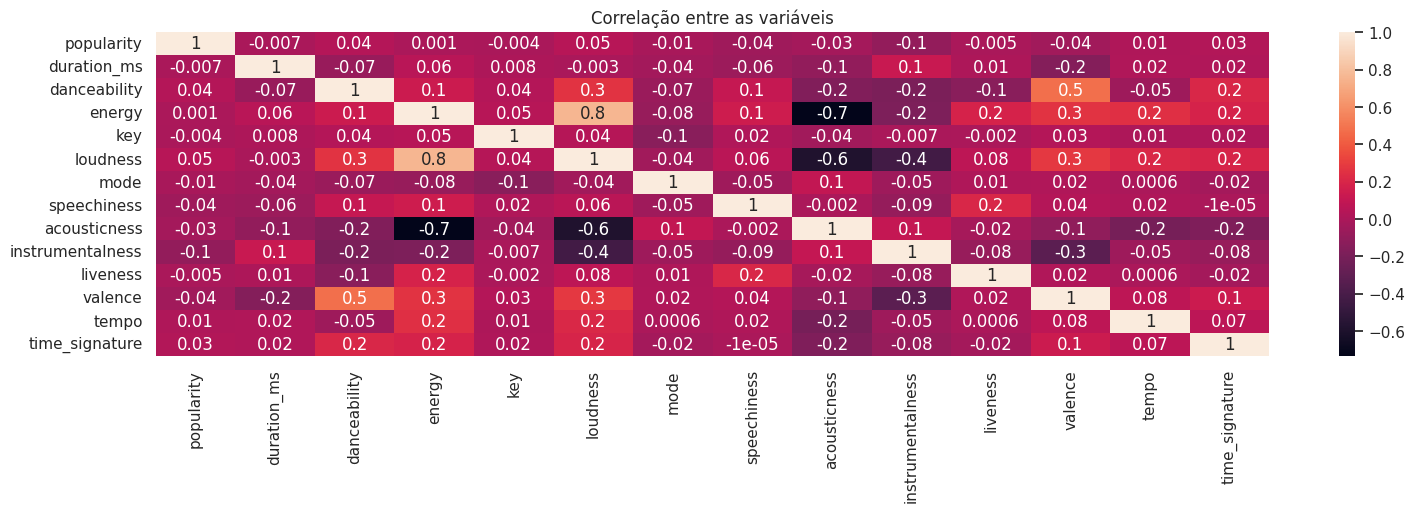

In [90]:
# Plotagem da tabela de correlação usando o Seaborn
plt.figure(figsize=(16, 4))
sns.heatmap(corr_table, annot=True, fmt=".1g")
plt.title("Correlação entre as variáveis")
plt.show()

## Dia 2 - Pré processamento dos dados

Preparar o conjunto de dados para o treinamento do modelo de Machine Learning

In [91]:
# Removendo itens duplicados

dados_musicas = dados_musicas.drop_duplicates()
dados_musicas.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [92]:
# Criando classes de popularidade
dados_musicas[dados_musicas["popularity"] >=80]

conditionlist = [
    (dados_musicas['popularity'] >= 80) ,
    (dados_musicas['popularity'] <80)]

choicelist = [1,0]
dados_musicas.loc[:, 'pop_classe'] = np.select(conditionlist, choicelist, default=0)
dados_musicas.loc[:, 'pop_classe'] = dados_musicas['pop_classe'].astype(int)

In [93]:
dados_musicas = dados_musicas.dropna() # Remover os valores nulos

In [94]:
dados_musicas.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'pop_classe'],
      dtype='object')

In [95]:
dados_musicas = dados_musicas.drop(columns=['popularity'])

In [96]:
dados_musicas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113549 non-null  object 
 1   artists           113549 non-null  object 
 2   album_name        113549 non-null  object 
 3   track_name        113549 non-null  object 
 4   duration_ms       113549 non-null  int64  
 5   explicit          113549 non-null  bool   
 6   danceability      113549 non-null  float64
 7   energy            113549 non-null  float64
 8   key               113549 non-null  int64  
 9   loudness          113549 non-null  float64
 10  mode              113549 non-null  int64  
 11  speechiness       113549 non-null  float64
 12  acousticness      113549 non-null  float64
 13  instrumentalness  113549 non-null  float64
 14  liveness          113549 non-null  float64
 15  valence           113549 non-null  float64
 16  tempo             113549 

In [97]:
df_quantitative = dados_musicas
cols_to_drop = []

for column in dados_musicas:
  if dados_musicas[column].dtype == 'object':
    cols_to_drop.append(column)
df_quantitative = df_quantitative.drop(columns=cols_to_drop)

print(f"Tamanho do dataset que vamos trabalhar: {df_quantitative.shape}")

Tamanho do dataset que vamos trabalhar: (113549, 15)


In [98]:
df_quantitative.head()

,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,pop_classe
0,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,0
1,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,0
2,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,0
3,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,0
4,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,1


In [99]:

df_quantitative = df_quantitative.drop(columns=['explicit'])
df_quantitative.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113549 entries, 0 to 113999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   duration_ms       113549 non-null  int64  
 1   danceability      113549 non-null  float64
 2   energy            113549 non-null  float64
 3   key               113549 non-null  int64  
 4   loudness          113549 non-null  float64
 5   mode              113549 non-null  int64  
 6   speechiness       113549 non-null  float64
 7   acousticness      113549 non-null  float64
 8   instrumentalness  113549 non-null  float64
 9   liveness          113549 non-null  float64
 10  valence           113549 non-null  float64
 11  tempo             113549 non-null  float64
 12  time_signature    113549 non-null  int64  
 13  pop_classe        113549 non-null  int64  
dtypes: float64(9), int64(5)
memory usage: 13.0 MB


In [100]:
# Normalizando os dados, deixando na mesma escala
df_quantitative_nm=(df_quantitative-df_quantitative.min())/(df_quantitative.max()-df_quantitative.min())
df_quantitative_nm.head()

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,pop_classe
0,0.042473,0.686294,0.4610,0.090909,0.791392,0.0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,0.8,0.0
1,0.026971,0.426396,0.1660,0.090909,0.597377,1.0,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,0.8,0.0
2,0.038679,0.444670,0.3590,0.000000,0.736123,1.0,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,0.8,0.0
3,0.036978,0.270051,0.0596,0.000000,0.573701,1.0,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,0.6,0.0
4,0.036389,0.627411,0.4430,0.181818,0.737103,1.0,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,0.8,1.0


### Dividindo o dataset (treino, validação e teste)

Para divisão do dataset, separou-se em treino e teste, sendo que o teste será dividido com 20% de todo o conjunto e será usado somente após o modelo ser escolhido e ajustado.

Já os dados de treino, serão separados em treino e validação. Sendo os dados de validação usados para comparação de diferentes modelos e hiperparâmetros.

Embora os modelos sejam testados e otimizados, é díficil prever se perfomará bem em produção, por isso, o acompanhamento inicial é importante para verificar se realmente funciona ou precisa de ajustes.

**Dados de treinamento:** usado para treinar o modelo.

**Dados de validação:** usado para comparação de diferentes modelos e hiperparâmetros.

**Dados de teste:** usado para comprovar que aquele modelo realmente funciona. São dados ignorados no treinamento e no processo de escolha de hiperparâmetros.



In [101]:
df_train, df_test = train_test_split(df_quantitative, test_size=0.2, random_state=42, shuffle=True)

In [102]:
# Visualizando as proporções da variável alvo
df_train.pop_classe.value_counts(normalize=True)

,proportion
pop_classe,
0,0.98941
1,0.01059


In [103]:
# Dividindo X e Y
X = df_train.drop('pop_classe', axis=1)
y = df_train.pop_classe

# Separando os dados mantendo a porcentagem de amostras em cada classe
StratifKfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [104]:
# Looping para separar os dados em treino e validação
for train_index, val_index in StratifKfold.split(X, y):

    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]

In [105]:
# checando as proporções da classe 1 na divisão
print(f'Dimensões: {X_train.shape, X_val.shape, y_train.shape, y_val.shape}\n')
print(f"Proporção do df_train para classe=1: {round(len(df_train[df_train.pop_classe==1]) / df_train.shape[0], 4)}\n")
print(f"Proporção de X_train para classe=1:  {round(len(y_train[y_train==1]) / X_train.shape[0], 4)}")
print(f"Proporção de X_val para classe=1:    {round(len(y_val[y_val==1]) / X_val.shape[0], 4)}")


Dimensões: ((72672, 13), (18167, 13), (72672,), (18167,))

Proporção do df_train para classe=1: 0.0106

Proporção de X_train para classe=1:  0.0106
Proporção de X_val para classe=1:    0.0106


## Dia 3 - Baseline do primeiro modelo e Validação do modelo

In [106]:
# Instanciando o modelo
logReg = LogisticRegression()

# Treinando o modelo
logReg.fit(X_train, y_train)

# Prevendo nos dados de treino
y_pred_base_train = logReg.predict(X_train)

# Prevendo nos dados de validação
y_pred_base_val = logReg.predict(X_val)

In [107]:
logReg.coef_.tolist()[0]

[-2.6178655184848226e-06,
 0.0403778246888889,
 -0.18143333390253627,
 0.002113972153083913,
 0.1604108650986017,
 -0.13839103075949982,
 -0.027185744061131153,
 -0.12978351708588418,
 -0.15079157529644382,
 -0.14514185697569734,
 -0.057228165840562444,
 -0.0057765593582595415,
 -0.4459241377889041]

In [108]:
df_coef = df_quantitative_nm.drop(columns='pop_classe')
df_coef.columns

Index(['duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature'],
      dtype='object')

In [109]:
data = {
    "Features": df_coef.columns,
    "Coef": logReg.coef_.tolist()[0]
}

df = pd.DataFrame(data)
df

,Features,Coef
0,duration_ms,-0.000003
1,danceability,0.040378
2,energy,-0.181433
3,key,0.002114
4,loudness,0.160411
5,mode,-0.138391
6,speechiness,-0.027186
7,acousticness,-0.129784
8,instrumentalness,-0.150792
9,liveness,-0.145142


In [110]:
print('Nos dados de TREINO:')

print('---' * 20)
print('Modelo:    Regressão Logística (baseline)\n')
print(f"accuracy:  {accuracy_score(y_train, y_pred_base_train)}")
print(f"precision: {precision_score(y_train, y_pred_base_train)}")
print(f"recall:    {recall_score(y_train, y_pred_base_train)}")
print(f"f1:        {f1_score(y_train, y_pred_base_train)}")
print()
print('---' * 20)
print('---' * 20)
print()
print('Nos dados de VALIDAÇÃO:')
print('---' * 20)
print('Modelo:    Regressão Logística (baseline)\n')
print(f"accuracy:  {accuracy_score(y_val, y_pred_base_val)}")
print(f"precision: {precision_score(y_val, y_pred_base_val)}")
print(f"recall:    {recall_score(y_val, y_pred_base_val)}")
print(f"f1:        {f1_score(y_val, y_pred_base_val)}")
print('---' * 20)

Nos dados de TREINO:
------------------------------------------------------------
Modelo:    Regressão Logística (baseline)

accuracy:  0.9894044473800088
precision: 0.0
recall:    0.0
f1:        0.0

------------------------------------------------------------
------------------------------------------------------------

Nos dados de VALIDAÇÃO:
------------------------------------------------------------
Modelo:    Regressão Logística (baseline)

accuracy:  0.9894313865800628
precision: 0.0
recall:    0.0
f1:        0.0
------------------------------------------------------------


### Reamostragem, teste e validação

In [111]:
# Dicionário dos classificadores
classifiers = {
    "LogisiticRegression": LogisticRegression(),
    "KNearest": KNeighborsClassifier(),
    "DecisionTreeClassifier": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier()
}

**Distribuição (Random UnderSampling)**

Para esta subamostragem, será utilizado um dos métodos da família Near-miss, da biblioteca imblearn que consiste selecionar amostras baseados na distância da classe majoritária com as amostras da classe minoritária, basicamente utilizando o modelo de KNN em seu framework.

In [112]:
# instanciando o método
undersample = NearMiss()

# transformando o conjunto de dados
X_under, y_under = undersample.fit_resample(X_train, y_train)

# resumindo a distribuição da nova classe
counter = Counter(y_under)
print(counter)

Counter({0: 770, 1: 770})


In [113]:
for nome, model in classifiers.items():

    model.fit(X_under, y_under)
    y_pred = model.predict(X_val)

    print(f'Modelo:    {nome}\n')
    print(f"Acurácia:  {accuracy_score(y_val, y_pred)}")
    print(f"Precisão: {precision_score(y_val, y_pred)}")
    print(f"Recall:    {recall_score(y_val, y_pred)}")
    print(f"F1:        {f1_score(y_val, y_pred)}")
    print('---' * 20)
    print('---' * 20)

Modelo:    LogisiticRegression

Acurácia:  0.48846810150272474
Precisão: 0.011591714071052915
Recall:    0.5625
F1:        0.022715322326217268
------------------------------------------------------------
------------------------------------------------------------
Modelo:    KNearest

Acurácia:  0.1747674354598998
Precisão: 0.010193275086047128
Recall:    0.8020833333333334
F1:        0.020130718954248367
------------------------------------------------------------
------------------------------------------------------------
Modelo:    DecisionTreeClassifier

Acurácia:  0.4829636153465074
Precisão: 0.016804957462451423
Recall:    0.8333333333333334
F1:        0.032945536909296816
------------------------------------------------------------
------------------------------------------------------------
Modelo:    Random Forest

Acurácia:  0.4601750426597677
Precisão: 0.01746461909063535
Recall:    0.90625
F1:        0.03426883308714919
----------------------------------------------------

In [114]:
# instanciando o método
oversample = RandomOverSampler(sampling_strategy='minority')

# transformando o conjunto de dados
X_over, y_over = oversample.fit_resample(X_train, y_train)

# resumindo a distribuição da nova classe
counter = Counter(y_over)
print(counter)

Counter({0: 71902, 1: 71902})


In [115]:
for nome, model in classifiers.items():

    model.fit(X_over, y_over)
    y_pred = model.predict(X_val)

    print(f'Modelo:    {nome}\n')
    print(f"Acurácia:  {accuracy_score(y_val, y_pred)}")
    print(f"Precisão: {precision_score(y_val, y_pred)}")
    print(f"Recall:    {recall_score(y_val, y_pred)}")
    print(f"F1:        {f1_score(y_val, y_pred)}")
    print('---' * 20)
    print('---' * 20)

Modelo:    LogisiticRegression

Acurácia:  0.571200528430671
Precisão: 0.01506254786826653
Recall:    0.6145833333333334
F1:        0.02940443558435086
------------------------------------------------------------
------------------------------------------------------------
Modelo:    KNearest

Acurácia:  0.9766059338360764
Precisão: 0.2472885032537961
Recall:    0.59375
F1:        0.34915773353751917
------------------------------------------------------------
------------------------------------------------------------
Modelo:    DecisionTreeClassifier

Acurácia:  0.9834865415313481
Precisão: 0.3448275862068966
Recall:    0.625
F1:        0.4444444444444444
------------------------------------------------------------
------------------------------------------------------------
Modelo:    Random Forest

Acurácia:  0.988220399625695
Precisão: 0.4576923076923077
Recall:    0.6197916666666666
F1:        0.5265486725663717
------------------------------------------------------------
------

Pelas análises, concebe-se que, o Random Forest é aquele com melhores métricas, em suma. Destarte, o método de balanceamento escolhido foi o Random Over-Sampling.

In [116]:
# Transformando os dados
X_train_array = X_train.values
X_val_array = X_val.values
y_train_array = y_train.values
y_val_array = y_val.values

In [117]:
# HIPERPARÂMETROS PARA RANDOM FOREST

# Número de árvores
n_estimators = [3,5,10,100]

# Número de features para considerar em cada split
max_features = [3,4,5,6,None]

# Número máximo de níveis da árvore
max_depth = [3,4,5,6,None]

# Pesos para cada classe
class_weight = ['balanced',None]

# Colocando os parâmetros definidos em um dicionário
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'class_weight': class_weight}

# Exibindo os parâmetros
pprint(random_grid)

{'class_weight': ['balanced', None],
 'max_depth': [3, 4, 5, 6, None],
 'max_features': [3, 4, 5, 6, None],
 'n_estimators': [3, 5, 10, 100]}


In [118]:
# Definindo listas vazias para receber os resultados da validação cruzada
accuracy_lst_rf = []
precision_lst_rf = []
recall_lst_rf = []
f1_lst_rf = []
auc_lst_rf = []


# Instanciando o RandomizedSearchCV para validação cruzada com o grid de parametros
rf_grid = RandomizedSearchCV(RandomForestClassifier(), random_grid, random_state=42)

# Iniciando o tempo e contador para o loop
start = time.time()
count = 0

# Looping para a validação cruzada
for train, test in StratifKfold.split(X_train_array, y_train_array):

    # Instanciando o pipeline com técnica de reamostragem
    pipeline_rf = imbalanced_make_pipeline(RandomOverSampler(sampling_strategy='minority'), rf_grid)

    # Executando o pipeline para treinar o modelo
    model_rf = pipeline_rf.fit(X_train_array[train], y_train_array[train])

    # Identificando os melhores parâmetros no treinamento
    best_est_rf = rf_grid.best_estimator_

    # Realizando as previsões com o resultado do treinamento
    prediction_rf = best_est_rf.predict(X_train_array[test])

    # Armazenando os resultados
    accuracy_lst_rf.append(pipeline_rf.score(X_train_array[test], y_train_array[test]))
    precision_lst_rf.append(precision_score(y_train_array[test], prediction_rf))
    recall_lst_rf.append(recall_score(y_train_array[test], prediction_rf))
    f1_lst_rf.append(f1_score(y_train_array[test], prediction_rf))
    auc_lst_rf.append(roc_auc_score(y_train_array[test], prediction_rf))

    # Identificando em qual loop está
    count = count + 1
    print(f"kfold nº: {count}")

    # Medindo o tempo de cada loop
    intervalo = time.time()
    print(f"tempo intermediário: {(intervalo - start)/60:.1f} minutos")
    print()

print('---' * 20)
print(f"melhores estimadores para RF: {rf_grid.best_params_}")

# Imprimindo a média dos resultados da validação cruzada
print('---' * 20)
print('Resultados')
print(f"accuracy:  {np.mean(accuracy_lst_rf)}")
print(f"precision: {np.mean(precision_lst_rf)}")
print(f"recall:    {np.mean(recall_lst_rf)}")
print(f"f1:        {np.mean(f1_lst_rf)}")
print(f"AUC:       {np.mean(auc_lst_rf)}")
print('---' * 20)

# Imprimindo o tempo total da validação cruzada
end = time.time()
print(f"Tempo do loop para validação cruzada: {(end - start)/60:.1f} minutos")

kfold nº: 1
tempo intermediário: 6.9 minutos

kfold nº: 2
tempo intermediário: 13.7 minutos

kfold nº: 3
tempo intermediário: 20.6 minutos

kfold nº: 4
tempo intermediário: 27.5 minutos

kfold nº: 5
tempo intermediário: 34.4 minutos

------------------------------------------------------------
melhores estimadores para RF: {'n_estimators': 100, 'max_features': 6, 'max_depth': None, 'class_weight': 'balanced'}
------------------------------------------------------------
Resultados
accuracy:  0.9877256735792267
precision: 0.436189571957474
recall:    0.5415584415584416
f1:        0.4829012838791454
AUC:       0.7670310627871861
------------------------------------------------------------
Tempo do loop para validação cruzada: 34.4 minutos


In [119]:
# Transformando o conjunto de dados
over = RandomOverSampler(sampling_strategy=0.1)
under = RandomUnderSampler(sampling_strategy=0.5)

# Instanciando um pipeline com os dois métodos
pipeline = Pipeline(steps=[('o', over), ('u', under)])

# Transformando o conjunto de dados
X_under_over, y_under_over = pipeline.fit_resample(X_train, y_train)

# Resumindo a distribuição da nova classe
counter = Counter(y_under_over)
print(counter)

Counter({0: 14380, 1: 7190})


In [120]:
for nome, model in classifiers.items():
  model.fit(X_under_over, y_under_over)
  y_pred = model.predict(X_val)

  print(f'Modelo:    {nome}\n')
  print(f"Acurácia:  {accuracy_score(y_val, y_pred)}")
  print(f"Precisão: {precision_score(y_val, y_pred)}")
  print(f"Recall:    {recall_score(y_val, y_pred)}")
  print(f"F1:        {f1_score(y_val, y_pred)}")
  print('---' * 20)
  print('---' * 20)

Modelo:    LogisiticRegression

Acurácia:  0.9755050366048329
Precisão: 0.00392156862745098
Recall:    0.005208333333333333
F1:        0.0044742729306487695
------------------------------------------------------------
------------------------------------------------------------
Modelo:    KNearest

Acurácia:  0.9063686904827435
Precisão: 0.07057484348321001
Recall:    0.6458333333333334
F1:        0.12724474089276552
------------------------------------------------------------
------------------------------------------------------------
Modelo:    DecisionTreeClassifier

Acurácia:  0.9564044696427588
Precisão: 0.14370546318289787
Recall:    0.6302083333333334
F1:        0.23404255319148937
------------------------------------------------------------
------------------------------------------------------------
Modelo:    Random Forest

Acurácia:  0.9874497715638245
Precisão: 0.43478260869565216
Recall:    0.625
F1:        0.5128205128205128
----------------------------------------------

Ajustando (tunning) do modelo selecionado
**negrito**
Vamos definir os hiperparâmetros para analisar a melhor performance com a validação cruzada, mas antes vamos colocar os dados no formato para o algoritmo receber.

Não foram definidos um range alto de hiperparâmetros por causa da quantidade de dados que além de exigir muito poder computacional o tempo também será elevado, mesmo com o RandomizedSearchCV ao invés do **GridSearchCV**.

A validação cruzada ou cross-validation é uma técnica no qual o avaliamos se o modelo generaliza, ou seja, se o modelo tem uma boa performance com diferentes amostras, sem overfitting.

In [121]:
# Definindo hiperparâmentos

# transformando os dados
X_train_array = X_train.values
X_val_array = X_val.values
y_train_array = y_train.values
y_val_array = y_val.values


#HIPERPARÂMETROS PARA RANDOM FOREST
# Número de árvores
n_estimators = [3,5,10,100]

# Número de features para considerar em cada split
max_features = [3,4,5,6,None]

# Número máximo de níveis da árvore
max_depth = [3,4,5,6,None]

# Pesos para cada classe
class_weight = ['balanced',None]

# Colocando os parametros definidos em um dicionário
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'class_weight': class_weight}

print(random_grid)

{'n_estimators': [3, 5, 10, 100], 'max_features': [3, 4, 5, 6, None], 'max_depth': [3, 4, 5, 6, None], 'class_weight': ['balanced', None]}


In [122]:
# Random Forest + Distribuição (Random Over-Sampling)

# Definindo listas vazias para receber os resultados da validação cruzada
accuracy_lst_rf = []
precision_lst_rf = []
recall_lst_rf = []
f1_lst_rf = []
auc_lst_rf = []

rf_grid = RandomizedSearchCV(RandomForestClassifier(), random_grid, random_state=42)

start = time.time()
count = 0

for train, test in StratifKfold.split(X_train_array, y_train_array):

  pipeline_rf = imbalanced_make_pipeline(RandomOverSampler(sampling_strategy='minority'), rf_grid)
  # executando o pipeline para treinar o modelo
  model_rf = pipeline_rf.fit(X_train_array[train], y_train_array[train])

  # Identificação dos melhores parâmetros no treinamento
  prediction_rf = best_est_rf.predict(X_train_array[test])
  # armazenando os resultados
  accuracy_lst_rf.append(pipeline_rf.score(X_train_array[test], y_train_array[test]))
  precision_lst_rf.append(precision_score(y_train_array[test], prediction_rf))
  recall_lst_rf.append(recall_score(y_train_array[test], prediction_rf))
  f1_lst_rf.append(f1_score(y_train_array[test], prediction_rf))
  auc_lst_rf.append(roc_auc_score(y_train_array[test], prediction_rf))

  # Identificando em qual loop está
  count += 1
  print(f"kfold nº: {count}")

  # Medindo o tempo de cada loop
  intervalo = time.time()
  print(f"tempo intermediário: {(intervalo - start)/60:.1f} minutos")
  print()

print('---' * 20)
print(f"melhores estimadores para RF: {rf_grid.best_params_}")

# imprimindo a média dos resultados da validação cruzada
print('---' * 20)
print('Resultados')
print(f"accuracy:  {np.mean(accuracy_lst_rf)}")
print(f"precision: {np.mean(precision_lst_rf)}")
print(f"recall:    {np.mean(recall_lst_rf)}")
print(f"f1:        {np.mean(f1_lst_rf)}")
print(f"AUC:       {np.mean(auc_lst_rf)}")
print('---' * 20)

# imprimindo o tempo total da validação cruzada
end = time.time()
print(f"Tempo do loop para validação cruzada: {(end - start)/60:.1f} minutos")


kfold nº: 1
tempo intermediário: 6.9 minutos

kfold nº: 2
tempo intermediário: 13.6 minutos

kfold nº: 3
tempo intermediário: 20.5 minutos

kfold nº: 4
tempo intermediário: 27.2 minutos

kfold nº: 5
tempo intermediário: 34.1 minutos

------------------------------------------------------------
melhores estimadores para RF: {'n_estimators': 100, 'max_features': 6, 'max_depth': None, 'class_weight': 'balanced'}
------------------------------------------------------------
Resultados
accuracy:  0.9877119136893059
precision: 0.5567169537268118
recall:    0.909090909090909
f1:        0.6891971748926718
AUC:       0.9507694806252989
------------------------------------------------------------
Tempo do loop para validação cruzada: 34.1 minutos


# Avaliação do modelo ajustado
A Receiver Operating Characteristic Curve (ROC curve) ou Curva Característica de Operação do Receptor, é uma representação gráfica que ilustra o desempenho (ou performance) de um sistema classificador binário à medida que o seu limite de discriminação varia. A curva ROC é também conhecida como curva de característica de operação relativa, porque o seu critério de mudança é resultado da operação de duas características (TP e FP).

A Curva ROC possui dois parâmetros:

- Taxa de verdadeiro positivo (True Positive Rate ou TPR), que é dado por TP/(TP + FN)
- Taxa de falso positivo (False Positive Rate ou FPR), que é dado por FP / (FP + TN)

Quanto mais superior à esquerda o valor melhor é, e vamos criar uma função para fazermos uma validação cruzada plotando o resultado de cada um dos splits e por fim a média do resultado.

AUC fornece uma medida agregada de desempenho em todos os limites de classificação possíveis, ou seja, como a probabilidade de que o modelo classifica um exemplo positivo aleatório mais alto do que um exemplo negativo aleatório.



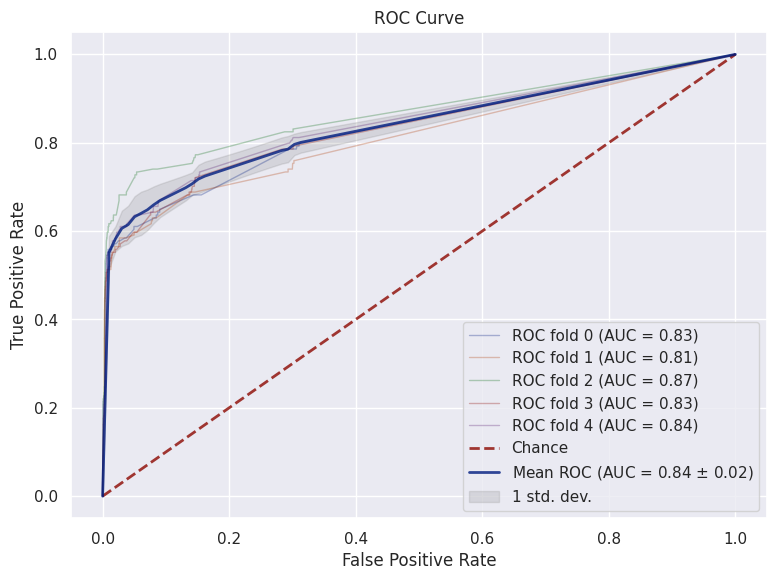

In [127]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.base import clone # Import clone for safety with estimators

def draw_cv_roc_curve(classifier_template, cv, X, y, title='ROC Curve'):
  tprs = []
  aucs = []
  mean_fpr = np.linspace(0, 1, 100)

  fig, ax = plt.subplots(figsize=(8, 6)) # Create a figure and axis for plotting

  for i, (train, test) in enumerate(cv.split(X, y)): # Use enumerate for fold index
    # Clone the classifier template to ensure a fresh, unfitted estimator for each fold
    classifier = clone(classifier_template)

    classifier.fit(X.iloc[train], y.iloc[train]) # Fit the classifier on the training data for the current fold
    probas_ = classifier.predict_proba(X.iloc[test]) # Get probability predictions on the test data for the current fold

    # Compute ROC curve and area under the curve
    fpr, tpr, thresholds = roc_curve(y.iloc[test], probas_[:, 1])
    tprs.append(np.interp(mean_fpr, fpr, tpr)) # Interpolate to common FPR points
    tprs[-1][0] = 0.0 # Ensure the first point is (0,0)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # Plot ROC curve for the current fold
    ax.plot(fpr, tpr, lw=1, alpha=0.3,
            label='ROC fold %d (AUC = %0.2f)' % (i, roc_auc))

  # Plot the random classifier line
  ax.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
          label='Chance', alpha=.8)

  # After the loop, calculate mean and standard deviation of ROC curves
  mean_tpr = np.mean(tprs, axis=0)
  mean_tpr[-1] = 1.0 # Ensure the last point is (1,1)
  mean_auc = auc(mean_fpr, mean_tpr)
  std_auc = np.std(aucs)
  # Plot the mean ROC curve
  ax.plot(mean_fpr, mean_tpr, color='b',
          label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
          lw=2, alpha=.8)

  # Plot the variability around the mean ROC curve
  std_tpr = np.std(tprs, axis=0)
  tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
  tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
  ax.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2,
                  label=r'1 std. dev.')

  # Customizing the plot
  ax.set_xlim([-0.05, 1.05])
  ax.set_ylim([-0.05, 1.05])
  ax.set_xlabel('False Positive Rate', fontsize=12)
  ax.set_ylabel('True Positive Rate', fontsize=12)
  ax.set_title(title)
  ax.legend(loc="lower right")

  # Display the plot
  plt.show()

# Executando função e plotando a Curva ROC AUC
draw_cv_roc_curve(best_est_rf, StratifKfold, X_train, y_train, title='ROC Curve')

### Modelo Final
Após a validação do modelo, será utilizado todos os dados de X e y, do dataset de treinamento para o modelo ifnal com os melhores hiperparâmetros encontrados na validação, definir o pipeline e treinar o modelo

In [128]:
x_all = df_train.drop('pop_classe', axis=1)
y_all = df_train['pop_classe']

# Instância do modelo final com os parâmetros encontrados na validação cruzada
final_model = rf_grid.best_estimator_

# Definindo o pipeline para reamostragem oversampling e o mdeolo final
pipeline = imbalanced_make_pipeline(RandomOverSampler(sampling_strategy='minority'), final_model)

# Treinando o modelo com os parâmetros ajustados com todos os dados
model = pipeline.fit(x_all, y_all)

In [129]:
model.steps[1]

('randomforestclassifier',
 RandomForestClassifier(class_weight='balanced', max_features=6))

In [130]:
lista = model.steps[1][1].feature_importances_

In [131]:
print(lista.tolist())

[0.08907777716894742, 0.09100801365943963, 0.11251325953479556, 0.0349289511077849, 0.12235677567776265, 0.005491192902249349, 0.0817017072535834, 0.1020380241592793, 0.10659170138820864, 0.08430677666023408, 0.08842863323717277, 0.07694121569359887, 0.00461597155694363]


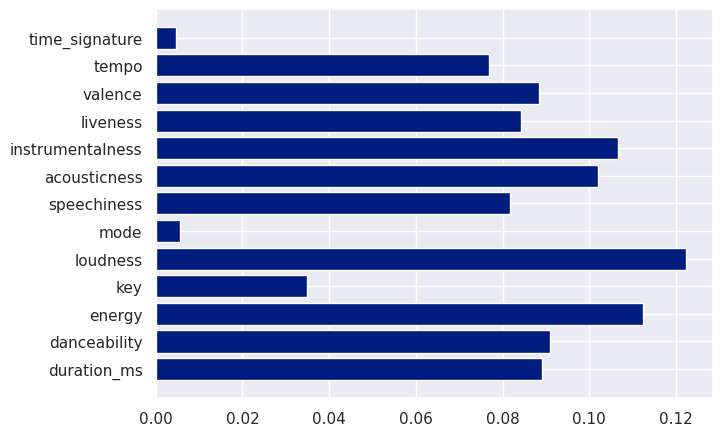

In [132]:
# Lista de nomes
nomes = df_quantitative_nm.columns

plt.barh(df_quantitative_nm.drop(columns=['pop_classe']).columns.tolist(), lista.tolist())

plt.show()

In [133]:
# Sugestão de remoção de correlação na etapa de pré-processamento

'''
Função que analisa a correlação entre as variáveis do banco de dados, cria uma
máscara para remover os dados espelhados e retorna os dados sem as variáveis
com correlação maior que o valor de corte 0.95.
'''

def remove_corr_var(dados, valor_corte = 0.95):

  matriz_corr = dados.iloc[:,4:-2].corr().abs()
  matriz_superior = matriz_corr.where(np.triu(np.ones(matriz_corr.shape), k=1).astype(np.bool))
  excluir = [coluna for coluna in matriz_superior.columns if any(matriz_superior[coluna]> valor_corte)]

  return dados.drop(excluir, axis=1)

Preparação, previsão e anvaliaçaõ nos dados de teste

In [134]:
# Separando os dados de teste
X_test = df_test.drop('pop_classe', axis=1)
y_test = df_test.pop_classe

y_pred_test = model.predict(X_test)
# Imprimindo os resultados
print(f"Accuracy:  {accuracy_score(y_test, y_pred_test)}")
print(f"Precision: {precision_score(y_test, y_pred_test)}")
print(f"Recall:    {recall_score(y_test, y_pred_test)}")
print(f"F1:        {f1_score(y_test, y_pred_test)}")

Accuracy:  0.9880228974020255
Precision: 0.45179063360881544
Recall:    0.6919831223628692
F1:        0.5466666666666666


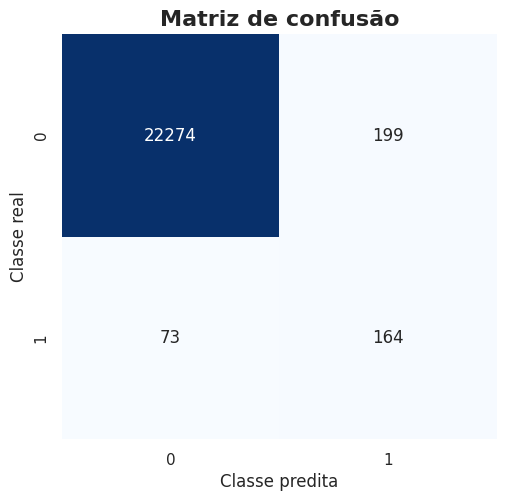

In [142]:
plt.figure(figsize=(5,5))
sns.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap='Blues', fmt='g', cbar=False)
plt.title("Matriz de confusão", fontsize=16, fontweight='bold')
plt.xlabel("Classe predita", fontsize=12)
plt.ylabel("Classe real", fontsize=12)
plt.show()

In [136]:
pd.DataFrame(index=['Baseline', 'Validação', 'Teste'],
             data = {"accuracy": [accuracy_score(y_val, y_pred_base_val), np.mean(accuracy_lst_rf), accuracy_score(y_test, y_pred_test)],
                     "precision": [precision_score(y_val, y_pred_base_val), np.mean(precision_lst_rf), precision_score(y_test, y_pred_test)],
                     "recall": [recall_score(y_val, y_pred_base_val), np.mean(recall_lst_rf), recall_score(y_test, y_pred_test)],
                     "f1": [f1_score(y_val, y_pred_base_val), np.mean(f1_lst_rf), f1_score(y_test, y_pred_test)]}
            )

,accuracy,precision,recall,f1
Baseline,0.989431,0.000000,0.000000,0.000000
Validação,0.987712,0.556717,0.909091,0.689197
Teste,0.988023,0.451791,0.691983,0.546667


In [137]:
# Antes de executar, deve ser criada a pasta modelo_versao1
# Salvando o modelo treinado no diretório atual
pkl_filename_model = "/RandomForestModel.pkl"
with open(pkl_filename_model, 'wb') as file:
    pickle.dump(model, file)

In [138]:
df_test['Predicted'] = y_pred_test

df_test['Correct?'] = np.where(df_test['pop_classe'] == df_test['Predicted'], 'Yes', 'No')

In [139]:
df_test.head()

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,pop_classe,Predicted,Correct?
77407,208512,0.427,0.703,9,-7.007,1,0.0487,0.575000,0.000000,0.9350,0.700,84.440,4,0,0,Yes
96769,105389,0.652,0.701,2,-8.178,1,0.0348,0.532000,0.000002,0.6020,0.928,158.124,4,0,0,Yes
6993,175906,0.573,0.976,1,-4.004,0,0.1790,0.000046,0.022200,0.2720,0.315,114.020,4,0,0,Yes
75387,284373,0.281,0.141,4,-19.125,0,0.0334,0.978000,0.883000,0.1030,0.206,135.356,3,0,0,Yes
61284,289280,0.403,0.921,9,-2.756,1,0.1100,0.032600,0.000000,0.0985,0.574,177.824,4,0,0,Yes


In [140]:
df_test[df_test['pop_classe'] == 1.0]

,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,pop_classe,Predicted,Correct?
68854,286040,0.813,0.560,2,-5.904,0,0.0618,0.1080,0.000000,0.2680,0.287,118.033,4,1,0,No
20367,172266,0.603,0.691,5,-5.805,1,0.0372,0.0248,0.000000,0.5830,0.577,147.148,4,1,0,No
57412,238640,0.515,0.430,7,-9.935,1,0.0372,0.0097,0.000133,0.1290,0.104,91.844,4,1,1,Yes
2105,329733,0.592,0.767,9,-2.788,0,0.0270,0.0021,0.001650,0.1270,0.328,96.483,4,1,1,Yes
51000,177391,0.860,0.541,1,-6.510,0,0.0325,0.1650,0.163000,0.0663,0.952,114.984,4,1,1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30562,166028,0.734,0.874,8,-3.158,1,0.0662,0.1680,0.000011,0.0489,0.905,122.953,4,1,0,No
53075,151475,0.845,0.797,1,-4.984,1,0.1390,0.0582,0.000006,0.1670,0.422,121.985,4,1,1,Yes
91610,224493,0.551,0.913,0,-4.063,0,0.0466,0.0263,0.000013,0.3470,0.544,119.992,4,1,1,Yes
88407,243716,0.650,0.715,5,-5.198,0,0.2530,0.0993,0.000291,0.1260,0.187,106.672,4,1,1,Yes


# Síntese do projeto - Predição de Popularidade Musical — Spotify Dataset
Projeto: 7 Days of Code | Machine Learning com dados do Spotify

Tipo: Classificação Binária Supervisionada

Dataset: 113.999 músicas com atributos acústicos extraídos via API do Spotify

## Objetivo
Desenvolver um modelo de Machine Learning capaz de prever se uma música atingirá alto índice de popularidade (score ≥ 80), a partir de atributos acústicos como danceability, energy, loudness e outros fornecidos pela API do Spotify.

## Etapas

1. Análise Exploratória (EDA)
Inspeção de distribuições, valores ausentes, artistas e gêneros mais populares. Matriz de correlação de Pearson para entender relações entre as features. Identificação do forte desbalanceamento da variável-alvo.

2. Pré-processamento
Remoção de duplicatas e nulos. Conversão da popularidade contínua em classe binária (pop_classe: 1 se ≥ 80, 0 caso contrário). Descarte de colunas categóricas e normalização min-max das features numéricas.

3. Modelagem e Comparação
Regressão Logística como baseline. Avaliação comparativa de quatro algoritmos (Logistic Regression, KNN, Decision Tree, Random Forest) sob três estratégias de reamostragem: NearMiss, RandomOverSampler e combinação over+under. Random Forest com oversampling apresentou as melhores métricas.

4. Tuning e Validação Cruzada
Otimização de hiperparâmetros via RandomizedSearchCV. Validação cruzada estratificada (StratifiedKFold, 5 folds) integrada ao pipeline do imbalanced-learn — garantindo que o resampling ocorre apenas dentro de cada fold de treino, sem data leakage.

5. Avaliação Final
Modelo avaliado no conjunto de teste isolado (20% dos dados, nunca vistos durante o desenvolvimento). Métricas: accuracy, precision, recall, F1 e AUC-ROC. Curva ROC plotada com intervalo de confiança. Modelo exportado via pickle.

**Tecnologias**

Python, pandas, numpy, scikit-learn, imbalanced-learn,seaborn, matplotlib, pickle

## Aprendizados
Em datasets desbalanceados, F1-score e AUC-ROC são métricas mais representativas que acurácia
Integrar o resampler dentro do pipeline de cross-validation evita data leakage
A análise de feature importance do Random Forest revelou que energy, loudness e danceability são os atributos com maior peso preditivo
A separação rigorosa treino/validação/teste garante uma estimativa honesta da generalização do modelo

## Considerações Finais

O projeto cobre o ciclo completo de ML supervisionado aplicado a um problema real: da exploração dos dados à exportação do modelo. O contexto de negócio — identificar músicas com potencial de alto engajamento — tem aplicação direta em plataformas de streaming, selos musicais e estratégias de curadoria de conteúdo.